In [1]:
import json
import math
import re
from collections import Counter
from augur.utils import json_to_tree
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.colorbar import ColorbarBase
import matplotlib.colors as mcolors

import pandas as pd
import numpy as np
from itertools import combinations

## Figure 6: The fitness effects of egg-adaptive mutations are not strictly additive: the occurrence of one mutation is influenced by the occurrence of another

In [2]:
def get_muts(virus, segment, gene):
    """
    Return all nonsyn muts in this gene
    """
    
    curated_mut_file = f"../egg-mutation-analysis/egg-muts-by-strain/{virus}_{segment}_curated-egg-muts.json"
    
    with open(curated_mut_file) as json_handle:
        egg_mut_info = json.load(json_handle)
        
    muts_by_strain = {}
        
    for strain, muts in egg_mut_info.items():
        
        muts_by_strain[strain] = muts.get(gene, [])

    return muts_by_strain

In [3]:
def get_timeframe(muts_by_strain, mut):
    """
    Find the min and max date this mut is observed at
    """
    # if we're looking for multiple AAs at this site
    if '|' in mut:
        mut = [mut.split('|')[0], mut.split('|')[0][:-1]+mut.split('|')[1]]
    else:
        mut = [mut]
    
    min_year = 2024
    max_year = 1994

    for k,v in muts_by_strain.items():
        k_year = int(k.split('/')[-1].strip('-egg'))
        for x in mut:
            if x in v:
                if k_year>max_year:
                    max_year = k_year
                if k_year<min_year:
                    min_year = k_year

    return min_year, max_year

In [4]:
def calc_individual_freq(muts_by_strain, mut, year_max, year_min):
    """
    Get the frequency of the specified mutation
    within the time frame, given by year_max and year_min
    Allow muts to be and/or for cases where AA seems interchangable. 
    For instance, 225G|N will give the freq of strains that have 225G OR 225N mut
    """
    # if we're looking for multiple AAs at this site
    if '|' in mut:
        mut = [mut.split('|')[0], mut.split('|')[0][:-1]+mut.split('|')[1]]
    else:
        mut = [mut]
    
    count_w_mut = 0
    count_wo_mut = 0
    
    for s, ms in muts_by_strain.items():
        s_year = int(s.split('/')[-1].strip('-egg'))
        # check if it's in the time frame
        if s_year >= year_min and s_year <= year_max:
            # then see if it has the mut or not
            has_mut = False
            for x in mut:
                if x in ms:
                    has_mut = True

            if has_mut==True:
                count_w_mut+=1
            else:
                count_wo_mut+=1
                
    mut_freq = count_w_mut/(count_w_mut+count_wo_mut)
    
    return mut_freq

In [5]:
def calc_pairwise_freq(muts_by_strain, muts, year_max, year_min):
    """
    For the pair of mutations, calculate the frequency of their co-occurrence
    within the time frame, given by year_max and year_min 
    """
    # if we're looking for multiple AAs at either site
    mutations = []
    for mut in muts:
        if '|' in mut:
            mut = [mut.split('|')[0], mut.split('|')[0][:-1]+mut.split('|')[1]]
        else:
            mut = [mut]
        mutations.append(mut)
    
    count_w_both = 0
    count_wo_both = 0
    
    for s, ms in muts_by_strain.items():
        s_year = int(s.split('/')[-1].strip('-egg'))
        # check if it's in the time frame
        if s_year >= year_min and s_year <= year_max:
            # then see if it has BOTH muts or not
            has_mut1 = False
            for x in mutations[0]:
                if x in ms:
                    has_mut1 = True
                    
            has_mut2 = False
            for x in mutations[1]:
                if x in ms:
                    has_mut2 = True

            if has_mut1==True and has_mut2==True:
                count_w_both+=1

            else:
                count_wo_both+=1
                
    both_freq = count_w_both/(count_w_both+count_wo_both)
    
    
    return both_freq

In [6]:
def calc_enrichment(virus, segment, gene, muts, year_max, year_min):
    """
    Calculate an enrichment/depletion score based on the excess 
    (or lack of) the 2 muts together, based on their individual frequencies
    """
    
    muts_by_strain = get_muts(virus, segment, gene)

    
    mut_freqs = []
    
    for mut in muts:
        mut_freq = calc_individual_freq(muts_by_strain, mut, year_max, year_min)
        mut_freqs.append(mut_freq)
        
    pairwise_freq = calc_pairwise_freq(muts_by_strain, muts, year_max, year_min)
    
    if pairwise_freq == 0.0:
        enrichment_score='never'
        
    else:
        enrichment_ratio = pairwise_freq/(mut_freqs[0] * mut_freqs[1])
        enrichment_score = math.log2(enrichment_ratio)
    
    return enrichment_score

In [7]:
def check_for_overlap(muts_by_strain, mut_pair, muts_in_overlap):
    """
    Find whether, between the 2 muts, at least 5 of each and at least 'muts_in_overlap' occur in the 
    period of time where the two mutations overlap
    """
    # if we're looking for multiple AAs at either site
    mutations = []
    for mut in mut_pair:
        if '|' in mut:
            mut = [mut.split('|')[0], mut.split('|')[0][:-1]+mut.split('|')[1]]
        else:
            mut = [mut]
        mutations.append(mut)
    
    timeframe1 = get_timeframe(muts_by_strain, mut_pair[0])
    timeframe2 = get_timeframe(muts_by_strain, mut_pair[1])
    timeframe_pair = (max(timeframe1[0], timeframe2[0]), min(timeframe1[1], timeframe2[1]))
    
    # count the number of each mut in the overlapping time period where both occur
    num_mut1_in_overlap = 0
    num_mut2_in_overlap = 0
    
    for k,v in muts_by_strain.items():
        k_year = int(k.split('/')[-1].strip('-egg'))
        # if the strain is within the time overlap
        if k_year >= timeframe_pair[0] and k_year <= timeframe_pair[1]:
            for x in mutations[0]:
                # check for mut
                if x in v:
                    num_mut1_in_overlap+=1
            for x in mutations[1]:
                # check for mut
                if x in v:
                    num_mut2_in_overlap+=1
            
    if num_mut1_in_overlap>5 and num_mut2_in_overlap>5:
        if num_mut1_in_overlap+num_mut2_in_overlap>=muts_in_overlap:
            muts_overlap = True
        else:
            muts_overlap = False
    else:
        muts_overlap = False
    
    return muts_overlap

In [8]:
def plot_matrix(virus, segment, gene, adaptive_muts, muts_in_overlap, ax):
    """
    Plot matrix of enrichment scores for all 
    For each pair, limit to the time frame where both are observed
    If there are fewer than 'muts_in_overlap' muts in the overlapping time period, then say they don't overlap
    """
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    muts_by_strain = get_muts(virus, segment, gene)
    
    # get period of overlap, if it is less than 3 years, muts don't overlap because of background
    # so don't calculate an enrichment score
    pairs_of_muts = list(combinations(adaptive_muts, 2))
    pairwise_results = []
    
    for pair in pairs_of_muts:
        timeframe1 = get_timeframe(muts_by_strain, pair[0])
        timeframe2 = get_timeframe(muts_by_strain, pair[1])
        timeframe_pair = (max(timeframe1[0], timeframe2[0]), min(timeframe1[1], timeframe2[1]))
        # check if these muts overlap in time
#         if timeframe_pair[1]-timeframe_pair[0] < time_overlap:
#             enrichment_score = 'no_overlap'
        
        muts_overlap = check_for_overlap(muts_by_strain, pair, muts_in_overlap)
        if muts_overlap == False:
            enrichment_score = 'no_overlap'
        
        elif muts_overlap == True:
            enrichment_score = calc_enrichment(virus, segment, gene, list(pair), 
                                               timeframe_pair[1], timeframe_pair[0])
        # have to add both orientations of the pair for heatmap?
        pairwise_results.append({'mut1': pair[0], 'mut2': pair[1], 'enrichment_score': enrichment_score})
        pairwise_results.append({'mut1': pair[1], 'mut2': pair[0], 'enrichment_score': enrichment_score})
    
    df = pd.DataFrame(pairwise_results)
    
    
    # pivot df to make heatmap
    heatmap_data = df.pivot("mut1", "mut2", "enrichment_score")
    
    
    # replace "never" and "no_overlap" with NaN for heatmap plotting
    heatmap_placeholder = heatmap_data.replace({"never": np.nan, "no_overlap": np.nan}).astype(float)
    # mask to only get the bottom triangle because otherwise you get each pair twice
    mask = np.triu(np.ones_like(heatmap_placeholder, dtype=bool))

    
    # Plot the heatmap
    sns.heatmap(
        heatmap_placeholder,
        mask=mask,
        annot=False, 
        cmap='vlag',
        center=0,
        vmin=-4,
        vmax=4,
        linewidths=1.0,
        linecolor="white", 
        cbar=False,
        ax=ax)


    # Overlay "no_overlap" and "never" with rectangles 
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            value = heatmap_data.iloc[i, j]
            if mask[i,j] == False:
                if value == "no_overlap":
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, 
                                               facecolor="#808080", lw=1, edgecolor='white'))
                elif value == "never":
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, 
                                               facecolor="darkblue", lw=1, edgecolor='white'))
    
    # Remove topmost row and rightmost column labels because these will be blank 
    # since there are no values for a mutation with itself
    
    # Get the labels and remove first for y and last for x
    y_tick_labels = [x for x in ax.get_yticklabels()]
    y_tick_labels[0] = ''
    
    # for x-tick labels, also split into two lines with residue number and then AAs
    if virus == 'h3n2':
        x_tick_labels = [x for x in ax.get_xticklabels()]
        x_tick_labels[-1] = ''
        ax.set_xticklabels(x_tick_labels, rotation=90, fontsize=12)
    else:
        adaptive_muts_2lines = [re.sub(r'(\d+)(.*)', r'\1\n\2', element) for element in adaptive_muts]
        x_tick_labels = [adaptive_muts_2lines[i] for i in range(len(adaptive_muts))]
        x_tick_labels[-1] = ''
        if virus in ['vic', 'yam']:
            ax.set_xticklabels(x_tick_labels, rotation=0, fontsize=11)
        else:
            ax.set_xticklabels(x_tick_labels, rotation=0, fontsize=12)
            
    
    ax.set_yticklabels(y_tick_labels, rotation=0, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')

    
    return ax

In [9]:
def plot_colorbar(ax):
    """
    Plot just one colorbar for all axes
    Include rectangles for "no_overlaop" and "never"
    """
    # set color scale same as heatmap
    sm = plt.cm.ScalarMappable(cmap='vlag', norm=plt.Normalize(vmin=-4, vmax=4))
    cbar = ColorbarBase(ax, cmap='vlag', norm=plt.Normalize(vmin=-4, vmax=4), orientation='vertical')
#     cbar = plt.colorbar(sm, cax=ax)
    ax.set_ylabel('Co-occurence\nenrichment score', rotation=-90, labelpad=20)
    #remove black outline
    cbar.outline.set_visible(False)
    
    #  dimensions for the rectangles
    rect_width = 1.0  
    rect_height = 0.13 
    y_start = -0.2  
    

    # Add rectangles underneath the colorbar
    ax.add_patch(
        patches.Rectangle(
            (0, y_start), rect_width, rect_height, 
            color='darkblue', transform=ax.transAxes, clip_on=False
        )
    )
    # Add the second rectangle stacked below the first
    ax.add_patch(
        patches.Rectangle(
            (0, y_start - rect_height - 0.06), rect_width, rect_height, 
            color='#808080', transform=ax.transAxes, clip_on=False
        )
    )
    
    # Add text annotations beside the rectangles
    label_x_offset = 1.3
    ax.text(label_x_offset, y_start + rect_height / 2, 'Overlap, but\nnever co-occur', ha='left', va='center', fontsize=8, transform=ax.transAxes)
    ax.text(label_x_offset, y_start - rect_height / 2 - 0.06, 'No temporal\noverlap', ha='left', va='center', fontsize=8, transform=ax.transAxes)



# Below is code to plot the number of adaptive muts per strain

In [10]:
# manually split some sites according to whether muts appear in different times frames (like 194I vs P)
adaptive_muts_by_virus = {'h3n2':{138:['S'], 156: ['Q','R'], 158: ['N'], 160: ['K', 'I'], 
                                  183: ['L'], 186: ['V', 'N', 'S'], 
                                  190: ['N', 'G', 'V'], 193: ['R'], 194: ['P', 'I'], 195: ['Y'], 196: ['T'], 
                                  203: ['I'], 219: ['Y','F'], 225: ['G', 'N'], 226: ['I'], 
                                  246: ['K', 'S', 'H', 'T']}, 
                          'h1n1pdm': {127: ['E'], 187: ['V', 'N', 'T'], 191: ['I'], 
                                      222: ['G', 'N'], 223: ['R']}, 
                          'vic': {141: ['R'], 196: ['S', 'D', 'K', 'T'], 198: ['I', 'A', 'N']}, 
                          'yam': {141: ['R'], 195: ['S', 'D', 'K'], 197: ['I', 'A', 'N', 'P']}}

In [11]:
def get_strain_year(virus, segment='ha'):
    """
    Return the year for all egg-passaged strains    
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    eggstrains_to_year = {}
    
    for node in tree.find_clades(terminal=True):
        passage = node.node_attrs['passage_category']['value']
        date = node.node_attrs['num_date']['value']
        year = math.trunc(date)
        if passage == 'egg':
            eggstrains_to_year[node.name] = year

            
    return eggstrains_to_year

In [12]:
def get_num_adaptive_muts_per_strain(virus):
    """
    Find the number of adaptive muts each strain has
    """
    # get year for each egg strain
    eggstrains_to_year = get_strain_year(virus)
    
    # get muts for each egg strain
    curated_mut_file = f"../egg-mutation-analysis/egg-muts-by-strain/{virus}_ha_curated-egg-muts.json"
    
    with open(curated_mut_file) as json_handle:
        egg_mut_info = json.load(json_handle)
    
    adaptive_muts_by_strain = []

    for strain, muts in egg_mut_info.items():
        year = eggstrains_to_year[strain]
        
        # find what muts this strain has
        adaptive_muts = []
        for g, m_list in muts.items():
            if g=='HA1':
                for m in m_list:
                    m_pos = int(m[:-1])
                    # if this is an adaptive mut, add it to the list
                    if m_pos in adaptive_muts_by_virus[virus].keys():
                        if m[-1] in adaptive_muts_by_virus[virus][m_pos]:
                            adaptive_muts.append(m)
                            
        # store strain name, adaptive muts and year
        adaptive_muts_by_strain.append({'virus': virus, 'strain': strain, 'year': year, 
                                        'num_adaptive': len(adaptive_muts), 'adaptive_muts': adaptive_muts})

    
    return adaptive_muts_by_strain

In [13]:
virus_cmap = {'A/H3N2': '#6C3BAA', 'A/H1N1pdm': '#45b6fe', 'B/Vic': '#FF4500', 'B/Yam': '#fbba0a'}


In [14]:
def plot_adaptive_muts_per_strain(ax):
    """
    Of the strains with an adaptive mut, plot how many have 2,3,4 etc muts
    """
    
    viruses = ['h3n2', 'h1n1pdm', 'vic', 'yam']
    prettify_names = {'h3n2': 'A/H3N2', 'h1n1pdm': 'A/H1N1pdm', 'vic': 'B/Vic', 'yam': 'B/Yam'}
    
    all_strain_muts = []
    
    for v in viruses:
        v_muts = get_num_adaptive_muts_per_strain(v)
        all_strain_muts+=v_muts
        
    df = pd.DataFrame(all_strain_muts)
    
    
    # strains that have adapted
    has_mut_df = df[df['num_adaptive']!=0]
    
    
    # get the count of strains with this many muts, per virus
    count_adaptive_muts = []
    for i, r in has_mut_df.groupby(['virus', 'num_adaptive']):
        v = i[0]
        num = i[1]
        count = len(r)
        count_adaptive_muts.append({'virus':prettify_names[v], 'num_adaptive_muts': num, 'count':count})
        
    count_adaptive_muts_df = pd.DataFrame(count_adaptive_muts)    
        
    # plot number with one adaptive mut, two, three etc
    g = sns.barplot(y='count', x='num_adaptive_muts', hue='virus', 
                hue_order= list(virus_cmap.keys()),
                palette = virus_cmap, 
                data=count_adaptive_muts_df, ax=ax)
    
    v_list = list(virus_cmap.keys())

    v_counter = 0
    last_x = -0.5
    for bar in g.patches:
        # plots all H3N2 first, then all H1N1pdm, etc
        # if x is greater than last x, then this is still plotting the same virus
        if bar.get_x()> last_x:
            v = v_list[v_counter]
        else:
            v_counter+=1
            v = v_list[v_counter]
        # update the last x pos seen
        last_x = bar.get_x()
        
        c = virus_cmap[v]

        height = bar.get_height()
        if not math.isnan(height):
            if v!='':

                ax.text(bar.get_x() + bar.get_width() / 2., height+18, int(height),
                            ha='center', va='center', color=c, fontsize=7.5)

        
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlabel('Number of Egg-Adaptive Mutations per Strain', fontsize=10)
    ax.set_ylabel('Number of\nEgg-passaged Strains', fontsize=10)
    
    sns.despine()
    
    return ax

In [16]:
def plot_fig6(muts_in_overlap=25, filename=None):
    """
    Muts are those from Fig 4, that appear at least 10 times, and at sites that mutate in 3% or more of strains
    """
    
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    fig = plt.figure(figsize=(6, 10))
    # plot heatmap of pairwise cooccurrence of adaptive muts
    # add row for blank space between viruses
    gs = GridSpec(nrows=8, ncols=5, width_ratios=[1,1,0.25, 0.15, 1], 
                  height_ratios=[1.15,1.35, 0.45, 0.5,0.15, 0.5, 0.25, 1.25])
    
    # plot number of adaptive muts per strain below
    # for some reason if I plot this at the end, axis lines get drawn on the heatmaps
    ax5 = fig.add_subplot(gs[7, 0:5])
    plot_adaptive_muts_per_strain(ax5)
    ax5.text(-0.08, 1.05, 'E', fontsize=20, transform=ax5.transAxes)
    
    # row 1 is H3N2
    # matrix
    ax1 = fig.add_subplot(gs[0:2, 0:5])
    plot_matrix('h3n2', 'ha', 'HA1', ['138S', '156Q|R', '160K|I', '183L', '186V', '186S', '186N', 
                                  '190G|V|N', '193R', '194P', '194I', '195Y', '196T',
                                  '203I', '219Y|F', '225G|N', '226I', '246S|H|T', '246K'], 
                muts_in_overlap, ax1)
    ax1.text(-0.12, 1.0, 'A', fontsize=20, transform=ax1.transAxes)
    ax1.text(0, 0.97, 'A/H3N2', fontsize=18, transform=ax1.transAxes)
    
    ax_cbar = fig.add_subplot(gs[0, 3])
    plot_colorbar(ax_cbar)
    
    # row 2 is H1N1pdm
    # matrix
    ax2 = fig.add_subplot(gs[3:6, 0:2])
    plot_matrix('h1n1pdm', 'ha', 'HA1', ['127E', '187V|N|T', '191I', '222G|N', '223R'], 
                muts_in_overlap, ax2)
    ax2.text(-0.15, 0.92, 'B', fontsize=20, transform=ax2.transAxes)
    ax2.text(0, 0.88, 'A/H1N1pdm', fontsize=18, transform=ax2.transAxes)

    
    # row 3 is Vic and Yam
    ax3 = fig.add_subplot(gs[3, 3:5])
    plot_matrix('vic', 'ha', 'HA1', ['141R', '196S|D|K|T', '198I|A|N'], 
                muts_in_overlap, ax3)
    ax3.text(-0.35, 0.88, 'C', fontsize=20, transform=ax3.transAxes)
    ax3.text(0, 0.78, 'B/Vic', fontsize=18, transform=ax3.transAxes)

    
    ax4 = fig.add_subplot(gs[5, 3:5])
    plot_matrix('yam', 'ha', 'HA1', ['141R', '195D|S|K', '197I|A|N|P'], 
                muts_in_overlap, ax4)
    ax4.text(-0.3, 0.98, 'D', fontsize=20, transform=ax4.transAxes)
    ax4.text(0, 0.82, 'B/Yam', fontsize=18, transform=ax4.transAxes)
    

    
    if filename:
        fig.savefig(filename, dpi=400, bbox_inches='tight', transparent=False, facecolor='white')
    

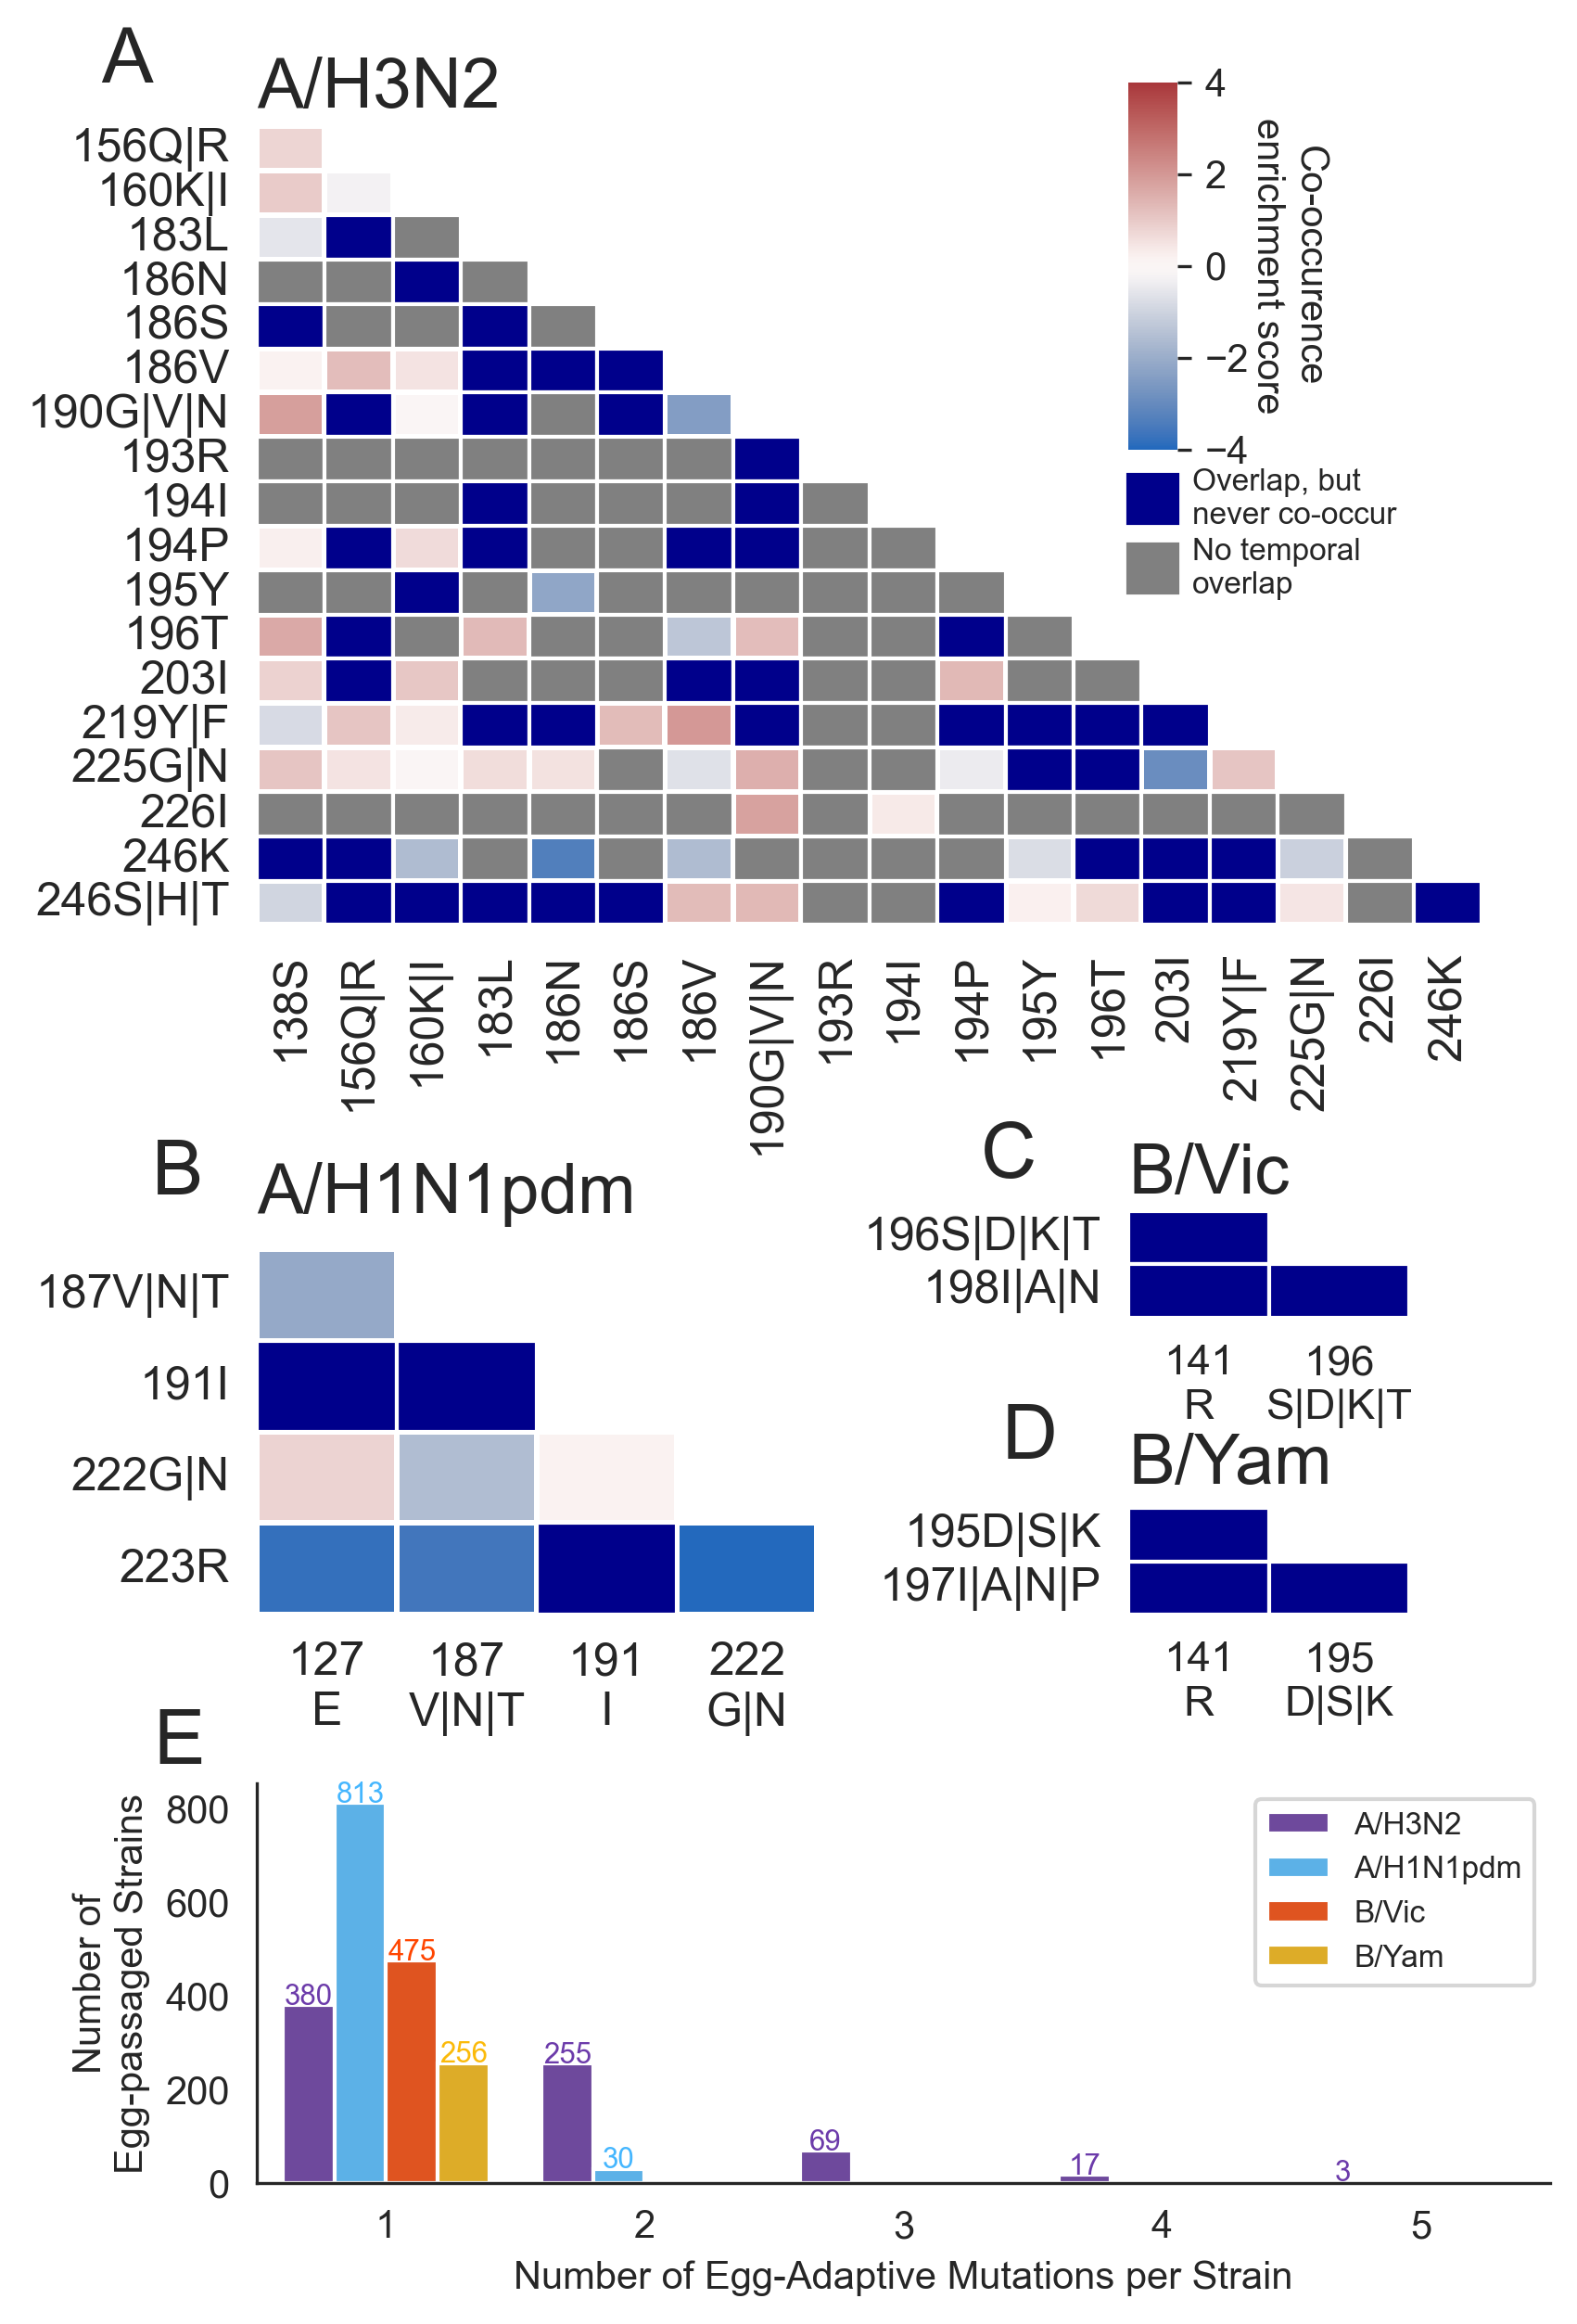

In [18]:
plot_fig6(filename='Figure6/Figure6.png')